In [1]:
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

#### 3.5.1 Defining the Model

In [2]:
class LinearRegression(d2l.Module):   #@save
    """The linear regression model implement with high-level APIs."""
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

In [3]:
@d2l.add_to_class(LinearRegression)   #@save
def forward(self, X):
    return self.net(X)

#### 3.5.2 Defining the Loss Function

In [5]:
@d2l.add_to_class(LinearRegression)   #@save
def loss(self, y_hat, y):
    fn = nn.MSELoss()
    return fn(y_hat, y)
# why not?                                                                                                     (???)
# return nn.MSELoss()(y_hat, y)

#### 3.5.3 Defining the Optimization Algorithm

In [6]:
@d2l.add_to_class(LinearRegression)   #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)

#### 3.5.4 Training

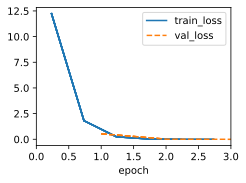

In [7]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [8]:
@d2l.add_to_class(LinearRegression)   #@save
def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)
w, b = model.get_w_b()

print(f'error in estimating w: {data.w - w.reshape(data.w.shape)}')
print(f'error in estimating b: {data.b - b}')

error in estimating w: tensor([ 0.0090, -0.0060])
error in estimating b: tensor([0.0103])


##### exercise_1
To make the result meet, lr_ave = n * lr_agg

##### ecercise_3
set `requires_grad = True` for weight and access it by using `weight.grad`

##### exercise_4
1. Changing the learning rate
   It enlarges the optimize step of graident, and may accelate the optimize progress, but may let the solution result in waving over the label or even moving further.
2. Changing the number of epochs
   May make the solution fit better but has risks of overfitting. 

<function matplotlib.pyplot.show(close=None, block=None)>

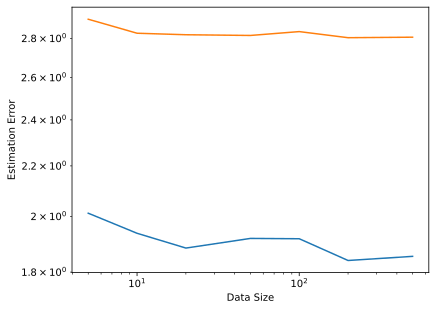

In [27]:
# exercise_5
import matplotlib.pyplot as plt

true_w, true_b = 2, 3

def generate_data(n):
    x = torch.randn(n, 1)
    y = true_w * x + true_b + torch.randn(n, 1)
    return x, y

def train_model(x, y, lr=0.03):
    w = torch.tensor([0.0], requires_grad=True)
    b = torch.tensor([0.0], requires_grad=True)
    y_hat = w * x + b
    loss = (y - y_hat) ** 2
    loss = loss.mean()
    loss.backward()
    w.data -= lr * w.grad
    b.data -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
    return w, b

data_sizes = [5, 10, 20, 50, 100, 200, 500]
w = []
b = []

for size in data_sizes:
    x, y = generate_data(size)
    w_hat, b_hat = train_model(x, y)
    w.append((true_w - w_hat).item())
    b.append((true_b - b_hat).item())

plt.plot(data_sizes, w)
plt.plot(data_sizes, b)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Data Size')
plt.ylabel('Estimation Error')
plt.show